In [1]:
# add autoreload
%load_ext autoreload
%autoreload 2

import os, sys
from dotenv import load_dotenv

from timex.ecg import dataset, tokenizer

from tslearn.piecewise import OneD_SymbolicAggregateApproximation, SymbolicAggregateApproximation, PiecewiseAggregateApproximation
from fABBA import JABBA, fABBA

from torch.utils.data import DataLoader

from transformers import (
    DataCollatorForLanguageModeling,
    Trainer,
    TrainingArguments,
    BigBirdForMaskedLM,
    BigBirdForPreTraining,
    BigBirdConfig
)
import torch

import numpy as np
np.set_printoptions(threshold=sys.maxsize)
import gc

from tqdm import tqdm

import matplotlib.pyplot as plt

load_dotenv('../.env')
BASE_DIR = os.getenv('ECG_DIR')

INFO:root:Initializing Config class


In [2]:
def count_parameters(model, trainable_only=False):
    """
    Return the number of parameters in `model`.
    If trainable_only=True, counts only params with requires_grad=True.
    """
    # HF models expose this:
    if hasattr(model, "num_parameters"):
        try:
            return model.num_parameters(only_trainable=trainable_only)
        except TypeError:
            pass  # older versions may not accept the arg

    # Generic PyTorch fallback
    return sum(p.numel() for p in model.parameters()
               if (p.requires_grad if trainable_only else True))

def humanize_params(n, precision=2):
    """Format an integer parameter count into K/M/B string."""
    for unit, div in (("B", 1e9), ("M", 1e6), ("K", 1e3)):
        if n >= div:
            return f"{n/div:.{precision}f}{unit}"
    return str(n)

In [3]:
nsegments = 200
SAX1d = OneD_SymbolicAggregateApproximation(n_segments=nsegments, 
                                            alphabet_size_avg=512, 
                                            alphabet_size_slope=512, 
                                            scale=False)
SAA = SymbolicAggregateApproximation(n_segments=nsegments, 
                                     alphabet_size_avg=1024, 
                                     scale=False)

PAA = PiecewiseAggregateApproximation(n_segments=nsegments)

ABBA = JABBA(verbose=1, init='kmeans')

In [4]:
PREPLIST = ['savgol', 'resampler', 'notch', 'bandpass'] #, 'detrend', 'peak_trimming']

In [5]:
ecgConfig = dataset.Config

In [6]:
ecgConfig.SAMPLING_RATE

500

In [ ]:
ECGDat = dataset.ECGDataset(data=os.path.join(BASE_DIR,
                                       'ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3',
                                       'records500'),
                       label_binarizer=None,
                       augmentations=[],
                       config = ecgConfig,                       
                       encode=False,
                       pretrain=False,
                       preprocessing=PREPLIST)

ECGDl_prep = DataLoader(ECGDat, batch_size=128, shuffle=False, collate_fn=ECGDat.collate)

# collect data for fitting
ecgConfig = dataset.Config
ecgConfig.SAMPLING_RATE = 500

results = []
for batch in tqdm(ECGDl_prep, desc="Processing ECG batches"):
    ecg_data, ecg_label, ecg_filenames, _ , ecg_metadata = batch
    for signal, label, metadata, filename in zip(ecg_data, ecg_label, ecg_metadata, ecg_filenames):
        results.append(np.array(signal).transpose())
results_concat = [r.ravel() for r in results]


First 5 elements of the file_list: ['T:\\laupodteam\\AIOS\\Bram\\data\\ECG\\ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3\\records500\\00000\\00969_hr.hea', 'T:\\laupodteam\\AIOS\\Bram\\data\\ECG\\ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3\\records500\\00000\\00106_hr.hea', 'T:\\laupodteam\\AIOS\\Bram\\data\\ECG\\ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3\\records500\\00000\\00483_hr.hea', 'T:\\laupodteam\\AIOS\\Bram\\data\\ECG\\ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3\\records500\\00000\\00545_hr.hea', 'T:\\laupodteam\\AIOS\\Bram\\data\\ECG\\ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3\\records500\\00000\\00133_hr.hea']
No labels available to show unique values


Processing ECG batches:  53%|█████▎    | 91/171 [10:20<08:16,  6.20s/it]

In [ ]:
results[0].shape

(5000, 12)

In [ ]:
print("Fitting SAA")
SAA.fit(results, y=None)

print("Fitting 1dSAX")
SAX1d.fit(results, y=None)

print("Fitting PAA")
PAA.fit(results, y=None)

# print("Fitting ABBA")
# ABBA.fit(np.vstack(results_concat[:5]), n_jobs=-1)

Fitting SAA
Fitting 1dSAX
Fitting PAA


PiecewiseAggregateApproximation(n_segments=200)

In [ ]:
tl = 5000
ts = 77
sym_test = SAA.transform([results[ts][:tl,:]])
inv_sym_test = SAA.inverse_transform(sym_test)[0]

sym_test_1d = SAX1d.transform([results[ts][:tl,:]])
inv_sym_test_1d = SAX1d.inverse_transform(sym_test_1d)[0]

sym_test_paa = PAA.transform([results[ts][:tl,:]])
inv_sym_test_paa = PAA.inverse_transform(sym_test_paa)[0]

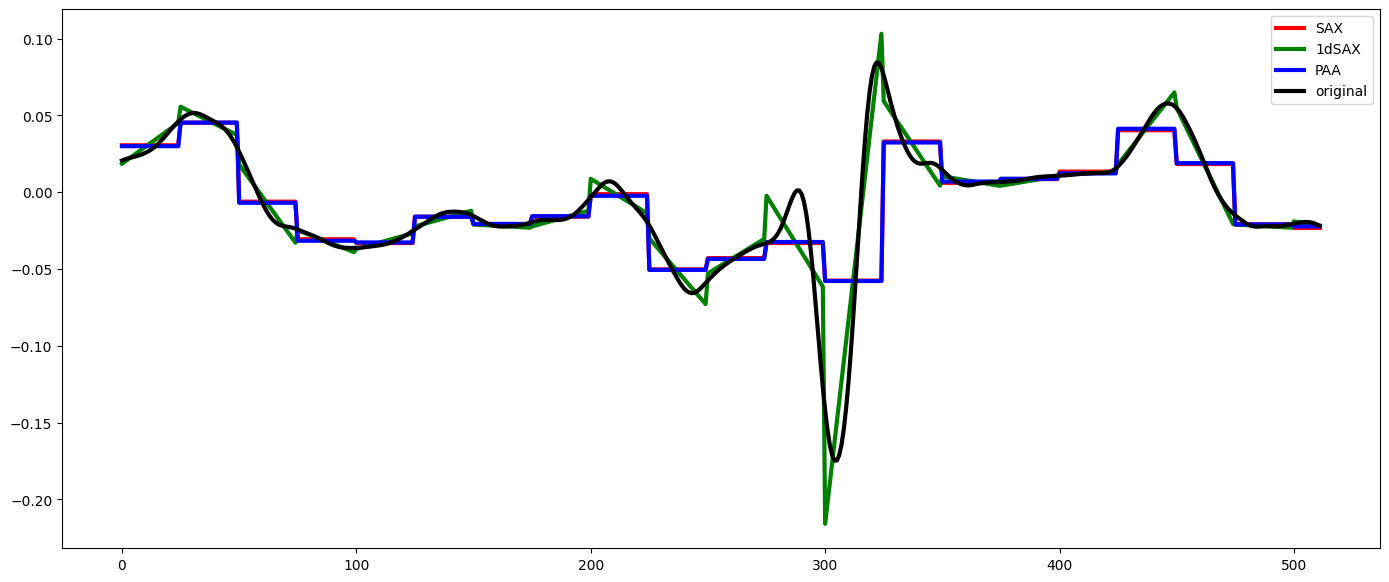

In [ ]:
channel = 2
s = 2600
length = 512
b, e = s, s + length
fig,ax=plt.subplots(figsize=(17,7))
plt.plot(inv_sym_test[b:e, channel], color='red', lw=3, label='SAX')
plt.plot(inv_sym_test_1d[b:e, channel], color='green', lw=3, label='1dSAX')
plt.plot(inv_sym_test_paa[b:e, channel], color='blue', lw=3, label='PAA')
plt.plot(results[ts][b:e, channel], color='black', lw=3, label='original')
plt.legend()

In [ ]:
# from scipy.signal import find_peaks

# #Trimming first and last peaks/dips
# def trim_signal(data):
#     trimmed_signals_list = []
#     for i in range(len(data)):
#         for j in range(len(data[i])):
#             peaks, _ = find_peaks(data[i][j], distance=30, prominence=(0.1))
#             dips, _ = find_peaks(-data[i][j], distance=250)

#             if len(peaks) == 0 or len(dips) == 0:
#                 trimmed_signals_list.append(data[i][j])
#                 continue

#             first_peak = peaks[0] if len(peaks) > 0 else len(data[i][j])
#             first_dip = dips[0] if len(dips) > 0 else len(data[i][j])

#             start_index = min(first_peak, first_dip) if first_peak != len(data[i][j]) or first_dip != len(data[i][j]) else 0

#             last_peak = peaks[-1] if len(peaks) > 0 else 0
#             last_dip = dips[-1] if len(dips) > 0 else 0

#             end_index = max(last_peak, last_dip) if last_peak != 0 or last_dip != 0 else len(data[i][j])
#             if start_index >= end_index:
#                 trimmed_signals_list.append(data[i][j])
#             else:
#                 trimmed_signals_list.append(data[i][j][start_index:end_index])

#     try:
#         trimmed_array = np.array(trimmed_signals_list)
#     except ValueError:
#         trimmed_array = np.array(trimmed_signals_list, dtype=object)

#     return trimmed_array.reshape(len(data), 12,)    




In [ ]:
# result = np.array(results).reshape(len(results),len(results[0][0]),len(results[0]))
# trimmed_array = trim_signal(result) #Shape:(n_signals, n_channels, ) inhomogeneous in third dimension

# concatenated = np.concatenate([np.concatenate(row) for row in trimmed_array])
# print(len(concatenated))


In [ ]:
# conc = concatenated.reshape(-1,1)  #For the sax fit

# sax = SymbolicAggregateApproximation(n_segments= 100, alphabet_size_avg=300, scale=False)
# sax_list = sax.fit(conc, y=None)
# my_tokenizer = tokenizer.ECGTokenizer(SAX_List = sax_list)
# encodings = my_tokenizer.encode(trimmed_array, symbolizer_model = 'sax')
# print(encodings[0])

# tok_ids = [encodings[i]["input_ids"] for i in range(len(encodings))]
# #decoded = my_tokenizer._decode(tok_ids)
# #print(decoded.shape)
# print(tok_ids[0])


In [ ]:
ECGDat = dataset.ECGDataset(data=os.path.join(BASE_DIR,
                                       'ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3',
                                       'records500'), pretrain=True, preprocessing=PREPLIST)
ECGTok = tokenizer.ECGTokenizer(SAX_List=SAA)
ECGDc = DataCollatorForLanguageModeling(ECGTok, mlm=True, mlm_probability=0.25)

def collate_tokenize_then_mask(batch):
    # batch: list[Tensor] shaped like [leads, T] each (whatever your dataset returns)
    signals = torch.stack(batch, dim=0)          # [B, leads, T]
    print(f"Collator produces: {signals.shape}")
    # tokenize -> list of dicts with "input_ids" + "attention_mask" (and optionally "special_tokens_mask")
    enc = ECGTok.encode(signals, padding=True, truncation=True)
    print(f"Tokenizer produces: {enc.shape}")
    examples = enc if isinstance(enc, list) else [enc]
    return ECGDc(examples)   

ECGDl = DataLoader(ECGDat, batch_size=128, shuffle=False, collate_fn=collate_tokenize_then_mask)

First 5 elements of the file_list: ['T:\\laupodteam\\AIOS\\Bram\\data\\ECG\\ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3\\records500\\00000\\00969_hr.hea', 'T:\\laupodteam\\AIOS\\Bram\\data\\ECG\\ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3\\records500\\00000\\00106_hr.hea', 'T:\\laupodteam\\AIOS\\Bram\\data\\ECG\\ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3\\records500\\00000\\00483_hr.hea', 'T:\\laupodteam\\AIOS\\Bram\\data\\ECG\\ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3\\records500\\00000\\00545_hr.hea', 'T:\\laupodteam\\AIOS\\Bram\\data\\ECG\\ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3\\records500\\00000\\00133_hr.hea']
No labels available to show unique values


In [ ]:
model_config = BigBirdConfig.from_pretrained('google/bigbird-roberta-base')
model_config.bos_token_id = ECGTok.bos_token_id
model_config.eos_token_id = ECGTok.eos_token_id
model_config.pad_token_id = ECGTok.pad_token_id
model_config.cls_token_id = ECGTok.cls_token_id
model_config.sep_token_id = ECGTok.sep_token_id
model_config.mask_token_id = ECGTok.mask_token_id
#model_config.additional_special_tokens = ["[BEAT]"]
model_config.vocab_size = ECGTok.vocab_size()

print(f"Tokenizer vocab_size: {ECGTok.vocab_size()}")
print(f"Special token IDs:")
print(f"  bos_token_id: {model_config.bos_token_id}")
print(f"  eos_token_id: {model_config.eos_token_id}")
print(f"  pad_token_id: {model_config.pad_token_id}")
print(f"  cls_token_id: {model_config.cls_token_id}")
print(f"  sep_token_id: {model_config.sep_token_id}")
print(f"  mask_token_id: {model_config.mask_token_id}")
print(f" beat_token_id: {ECGTok.beat_token_id}")

Tokenizer vocab_size: 1032
Special token IDs:
  bos_token_id: 1
  eos_token_id: 2
  pad_token_id: 0
  cls_token_id: 4
  sep_token_id: 5
  mask_token_id: 6
 beat_token_id: 7


In [ ]:
# account for beat and channel tokens?
ECGTok.model_max_length = getattr(ECGTok, "max_length", 2400) # 12 * 200 segments
model_config.max_position_embeddings = 2400

ECGModel = BigBirdForPreTraining(model_config)

In [ ]:
print(f"""Hidden size: {model_config.hidden_size} \n
Num hidden layers: {model_config.num_hidden_layers} \n
Num att heads: {model_config.num_attention_heads} \n
Intermediate size: {model_config.intermediate_size} \n
Max positional emb: {model_config.max_position_embeddings} \n
Max block size: {model_config.block_size} \n
Model parameters est: {humanize_params(count_parameters(ECGModel))}
""")

Hidden size: 768 

Num hidden layers: 12 

Num att heads: 12 

Intermediate size: 3072 

Max positional emb: 2400 

Max block size: 64 

Model parameters est: 88.88M



In [ ]:
ECGTrainingArgs = TrainingArguments(do_train=True, gradient_checkpointing=True, 
                                    num_train_epochs=1, logging_steps=10,
                                    per_device_train_batch_size=32,
                                    per_device_eval_batch_size=128)

In [ ]:
ECGTrainer = Trainer(ECGModel, 
                     args=ECGTrainingArgs,
                     train_dataset=ECGDat,
                     data_collator=collate_tokenize_then_mask,
                     processing_class=ECGTok)

In [71]:
ECGTrainer.train()

Collator produces: torch.Size([8, 12, 5000])
Padded signals: (8, 5000, 12)


ValueError: Number of features of the provided timeseries(last dimension) must match the one of the fitted data! ((np.int64(21799), np.int64(5000), np.int64(12)) and (1, 12, 1) are passed shapes)